# Synent Technologies Internship – Task 7
## Time Series Analysis of Apple Stock Prices
### Developed by: Shivansh Dalvadi

In [ ]:
pip install pandas numpy matplotlib seaborn yfinance statsmodels

## Importing Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('ggplot')

## Data Collection using Yahoo Finance

In [3]:
df = yf.download('AAPL', start='2020-01-01', end='2025-01-01')

[*********************100%***********************]  1 of 1 completed


## Data Exploration

In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377785,152.899565,149.680871,151.223469,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163700,55.160698,51.324796,55.059309,2.323470e+07
25%,126.279123,127.397093,124.278536,125.724391,5.546825e+07
50%,149.968597,151.709757,148.037172,149.788913,7.628335e+07
75%,175.902020,177.452425,174.337241,175.708231,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


## Data Cleaning

In [7]:
df.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [8]:
df.reset_index(inplace=True)

In [10]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2020-01-02,72.333885,72.394093,71.091191,71.344062,135480400
1,2020-01-03,71.630638,72.389257,71.406666,71.563205,146322800
2,2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
3,2020-01-07,71.861839,72.466322,71.642681,72.211041,108872000
4,2020-01-08,73.017830,73.318870,71.565614,71.565614,132079200


### Observations
- The dataset contains Apple stock price data from 2020 to 2025.
- Total 1258 records are available.
- Dataset contains Open, High, Low, Close, and Volume columns.
- No missing values were found in the dataset.
- Stock prices show large variation over time.

## Trend Analysis

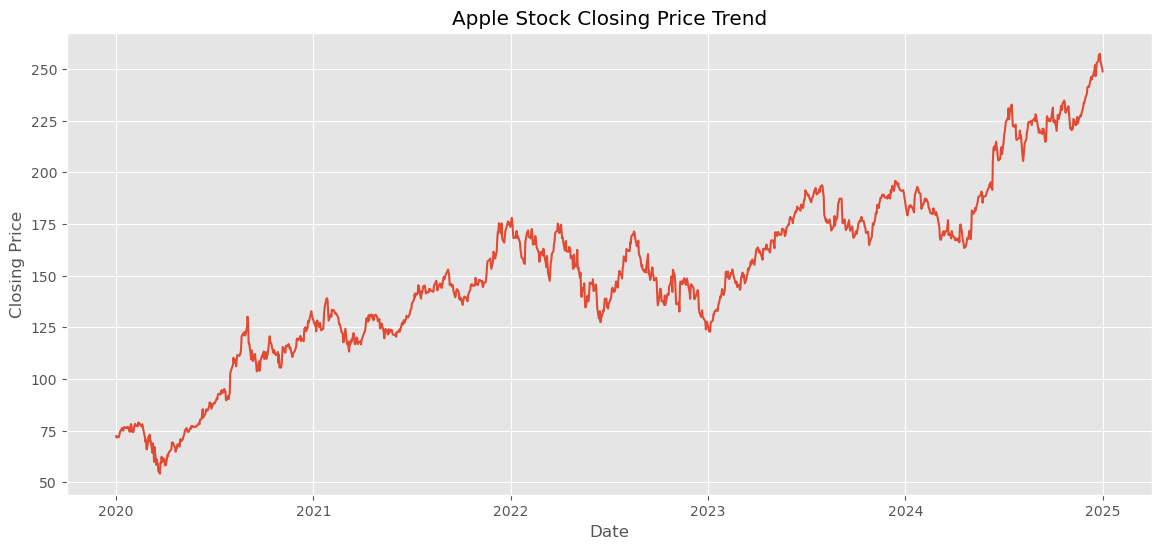

In [11]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'])

plt.title('Apple Stock Closing Price Trend')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.show()

### Insights from Closing Price Trend
- Apple stock prices show a strong upward trend from 2020 to 2025.
- A major dip is visible in early 2020, likely due to market uncertainty.
- After 2020, stock prices gradually recovered and continued increasing.
- Significant growth is observed during 2024 and early 2025.
- Overall market sentiment for Apple stock appears bullish.

## Trading Volume Analysis

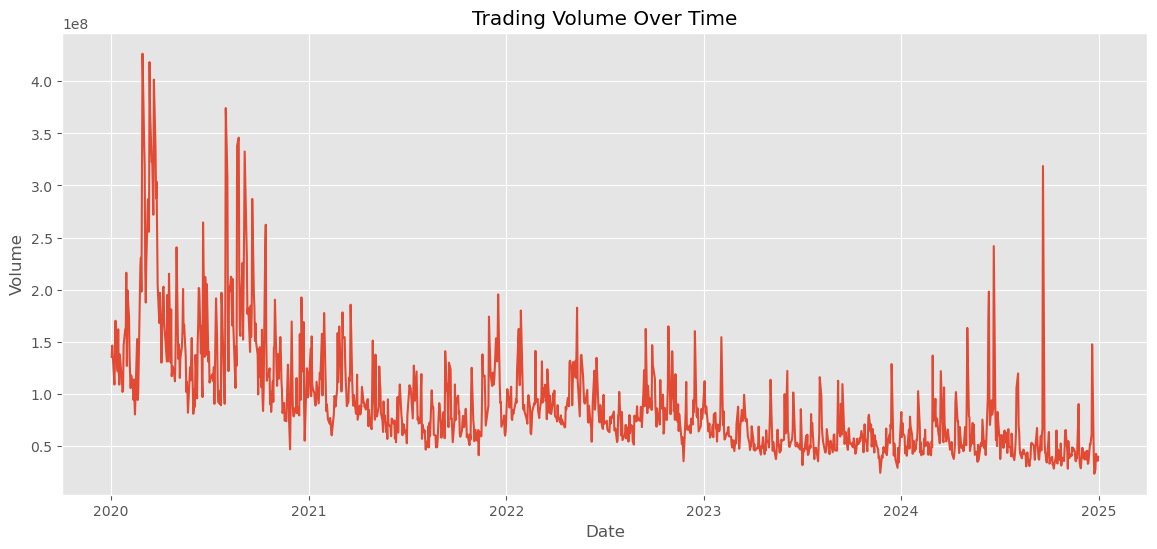

In [12]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Volume'])

plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

### Insights from Trading Volume
- Trading volume was extremely high during 2020.
- Volume gradually stabilized after 2021.
- Sudden spikes indicate periods of high market activity.
- Higher trading volume often corresponds to major market events.
- Recent trading volume appears comparatively stable.

## Moving Average Analysis

In [13]:
df['MA30'] = df['Close'].rolling(window=30).mean()

In [14]:
df['MA100'] = df['Close'].rolling(window=100).mean()

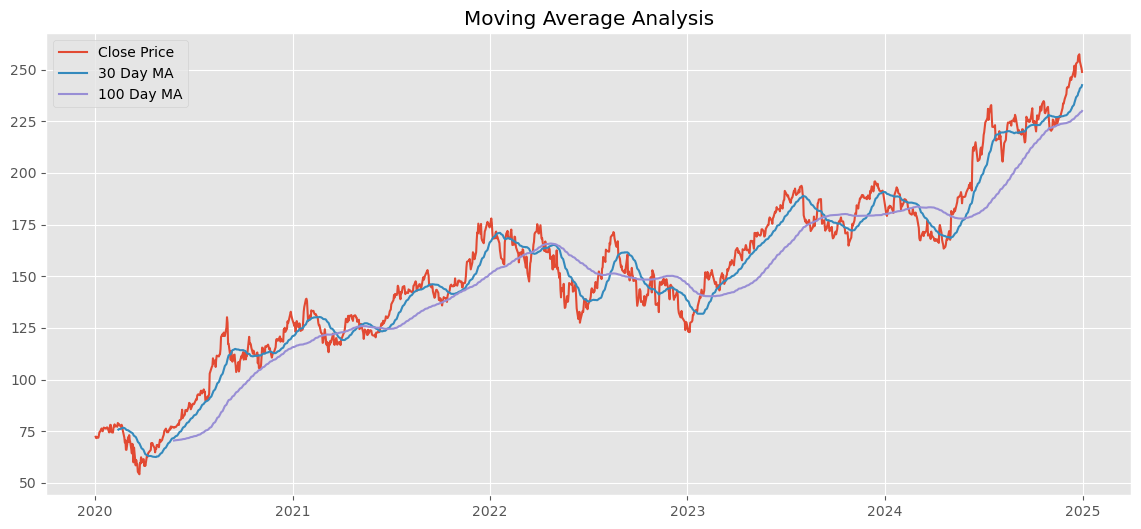

In [15]:
plt.figure(figsize=(14,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA30'], label='30 Day MA')
plt.plot(df['Date'], df['MA100'], label='100 Day MA')

plt.legend()

plt.title('Moving Average Analysis')

plt.show()

### Insights from Moving Average Analysis
- The 30-day moving average reacts faster to price changes.
- The 100-day moving average shows long-term trend direction.
- Stock prices remain mostly above the 100-day moving average.
- Crossovers between moving averages indicate bullish and bearish phases.
- Long-term trend remains positive throughout most of the dataset.

## Daily Return Distribution

In [16]:
df['Daily Return'] = df['Close'].pct_change()

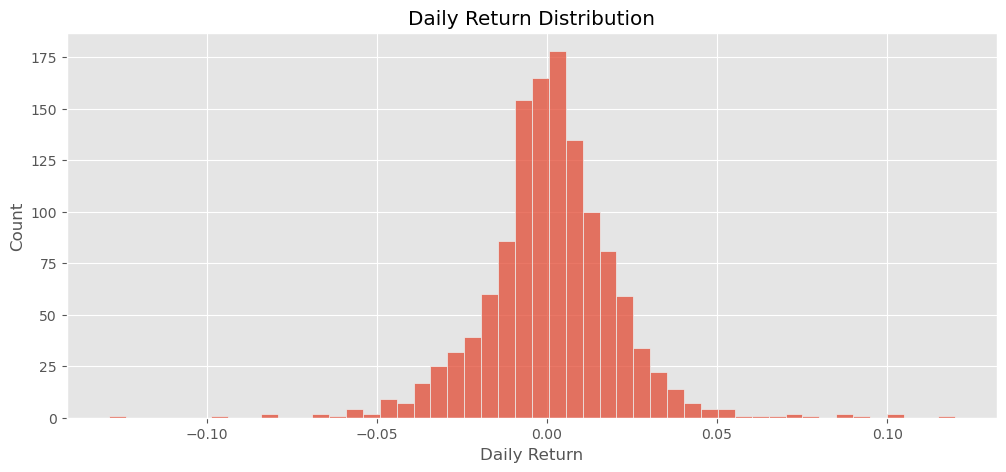

In [17]:
plt.figure(figsize=(12,5))

sns.histplot(df['Daily Return'].dropna(), bins=50)

plt.title('Daily Return Distribution')

plt.show()

### Insights from Daily Return Distribution
- Most daily returns are concentrated near zero.
- This indicates moderate day-to-day fluctuations.
- Extreme positive and negative returns are less frequent.
- Distribution resembles a normal distribution with some outliers.
- Stock market volatility is visible during certain periods.

## Seasonality Detection

In [18]:
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [19]:
decomposition = seasonal_decompose(df['Close'], model='additive', period=30)

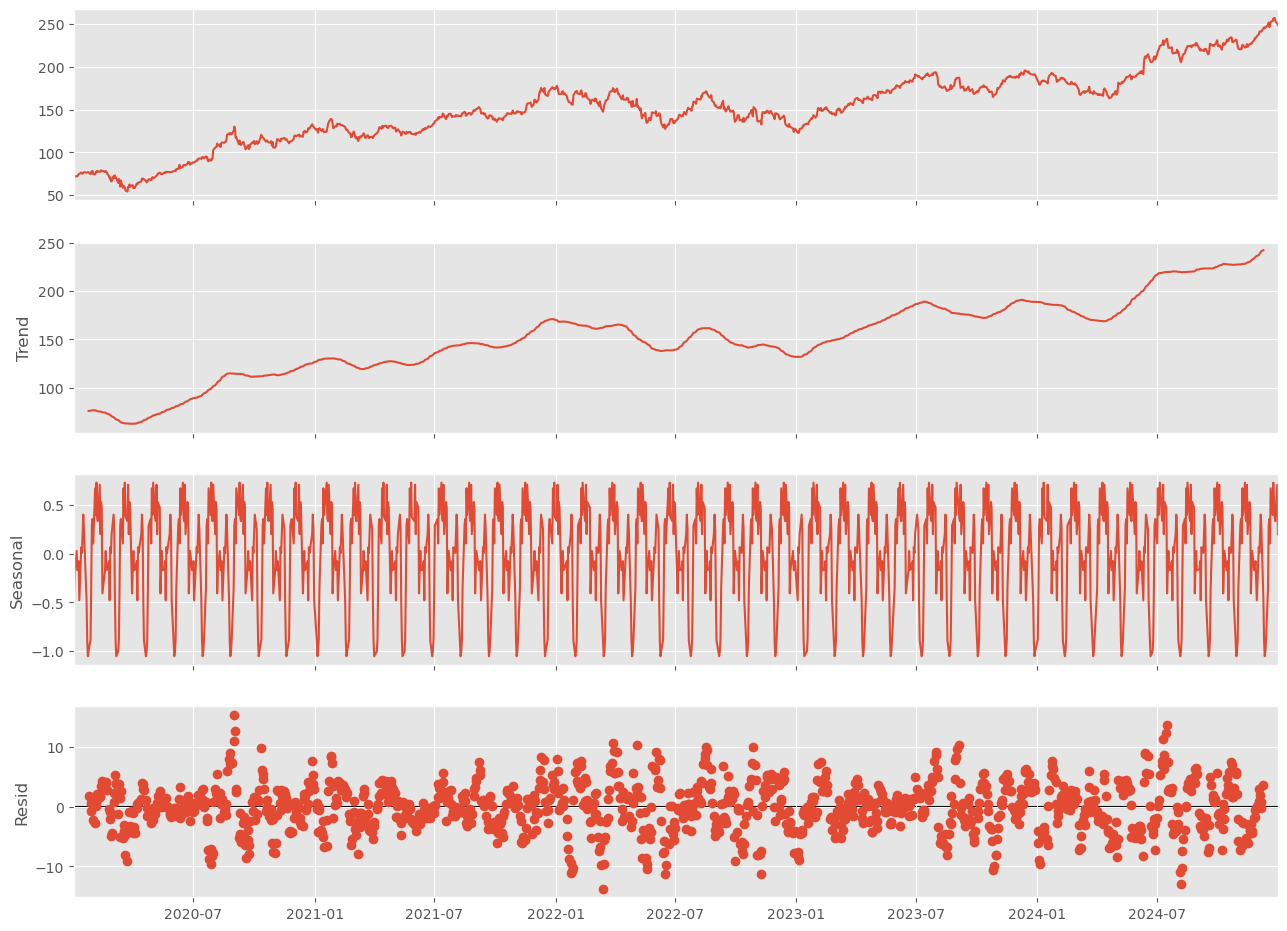

In [20]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.show()

### Insights from Seasonal Decomposition
- The trend component shows long-term stock price growth.
- Seasonal patterns repeat regularly over time.
- Residual values represent random market fluctuations.
- Some irregular spikes are visible in residuals due to market volatility.
- Trend component confirms overall upward movement in Apple stock prices.

## Forecasting using Prophet

In [21]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.1 MB/s eta 0:00:11
   -- ------------------------------------- 0.8/12.1 MB 1.1 MB/s eta 0:00:11
   --- ------------------------------------ 1.0/12.1 MB 1.0 MB/s eta 0:00:12
   ---- ----------------------------------- 1.3/12.1 MB 1.1 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/12.1 MB 1.0 MB/s eta 0:00:11
   ----- ---------------------------------- 1.6/12.1 MB 1.0 MB/s eta 0:00:11
   ------ --------------------------------- 1.8/12.1 MB 1.0 MB/s eta 0:00:10
   ------ --------------------------------- 2.1/12.1 MB 1.1 MB/s eta 0:00:10
   ------ ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [22]:
from prophet import Prophet

In [23]:
forecast_df = df.reset_index()[['Date', 'Close']]

forecast_df.columns = ['ds', 'y']

In [24]:
model = Prophet()

model.fit(forecast_df)

17:48:22 - cmdstanpy - INFO - Chain [1] start processing
17:48:34 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future = model.make_future_dataframe(periods=30)

In [26]:
forecast = model.predict(future)

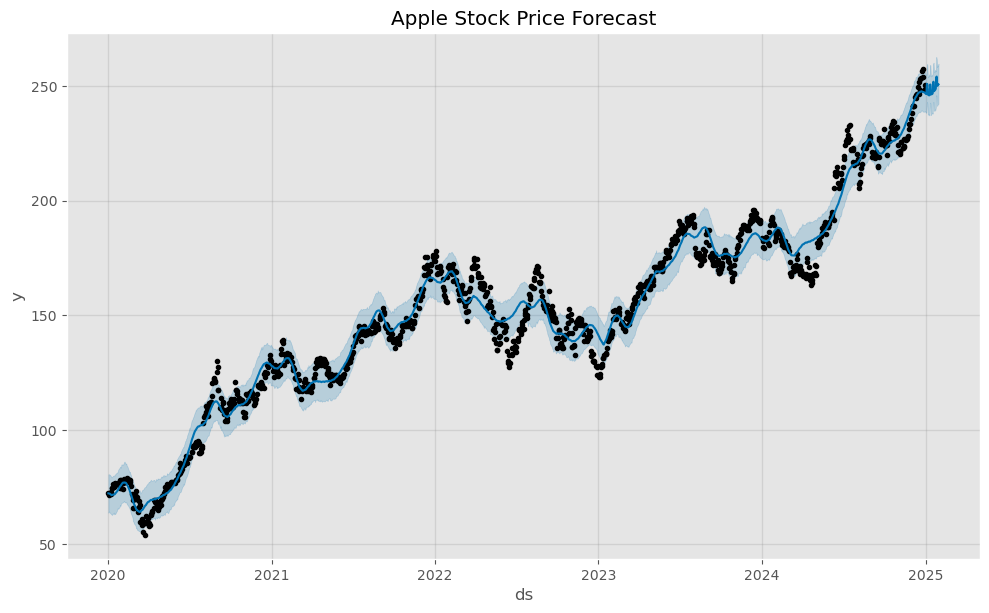

In [28]:
model.plot(forecast)
plt.title("Apple Stock Price Forecast")
plt.show()

### Insights from Forecasting
- Prophet model successfully captured historical stock trends.
- Forecast indicates continued growth in Apple stock prices.
- Confidence intervals widen in future predictions due to uncertainty.
- Predicted values closely follow historical market patterns.
- Model provides useful future trend estimation for short-term forecasting.

## Forecast Components

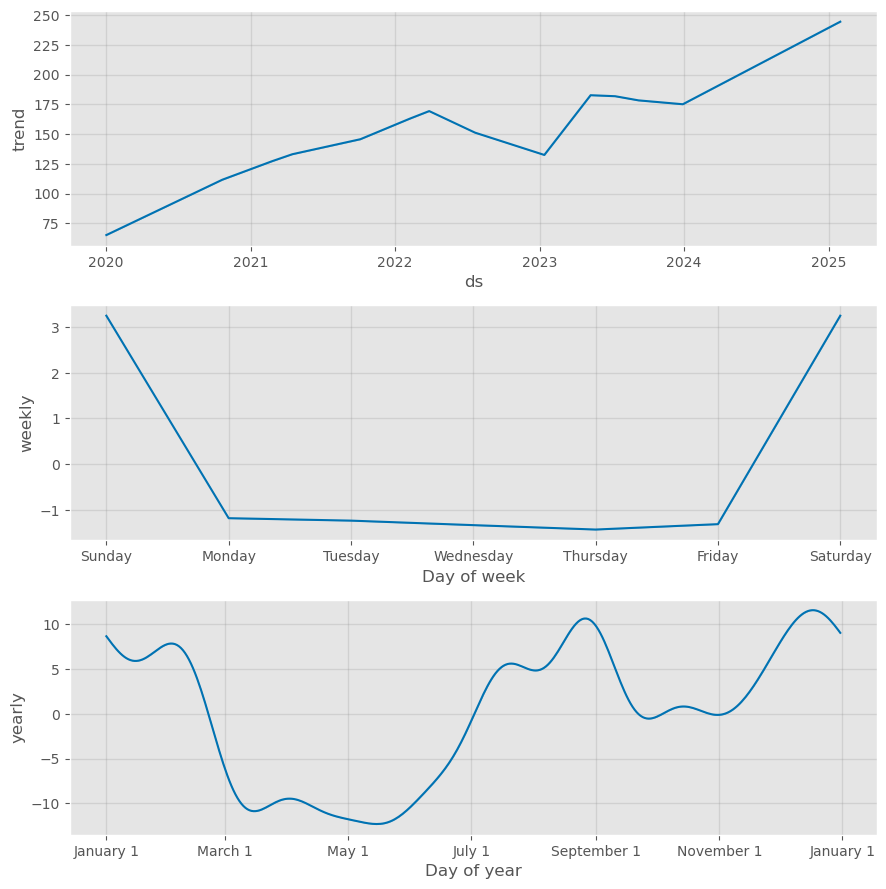

In [29]:
model.plot_components(forecast)

plt.show()

### Insights from Forecast Components
- Trend component shows steady long-term growth.
- Weekly seasonality indicates slight variations across weekdays.
- Yearly seasonality reveals recurring annual market patterns.
- Seasonal effects are smaller compared to overall trend growth.
- Apple stock demonstrates strong long-term performance.

## Final Insights and Conclusion


This project performed time series analysis on Apple stock price data using Python libraries such as Pandas, Matplotlib, Seaborn, Statsmodels, and Prophet.

The analysis identified:
- Strong long-term upward trend
- Stable seasonal patterns
- Moderate market volatility
- Positive future growth predictions

Moving averages and seasonal decomposition helped understand trend behavior, while Prophet forecasting provided future stock price estimation.

Overall, Apple stock demonstrated strong market performance over the analyzed period.